In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Pandas Tips

In [25]:
# import dataset
df = sns.load_dataset('titanic')
# check the dataset
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Missing values and imputing them

In [26]:
# find out the percentage of missing values in each column
df.isnull().sum()/ len(df) * 100

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [27]:
# drop the deck column from the dataset
df.drop('deck',axis =1,inplace = True)

In [28]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [29]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')

In [30]:
# mean of the age column
df['age'].mean()

np.float64(29.69911764705882)

In [31]:
# median of the age column

df['age'].median()

np.float64(28.0)

In [32]:
# mode of the age column

df['age'].mode()

0    24.0
Name: age, dtype: float64

In [33]:
import warnings
warnings.filterwarnings('ignore')

In [34]:
# filling missing values of column age with mean value of age column
df['age'].fillna(df['age'].mean(),inplace = True)

In [35]:
# fill embarked and embark_town with mode value
df['embarked'].fillna(df['embarked'].mode()[0],inplace = True)
df['embark_town'].fillna(df['embark_town'].mode()[0],inplace = True)

<Axes: >

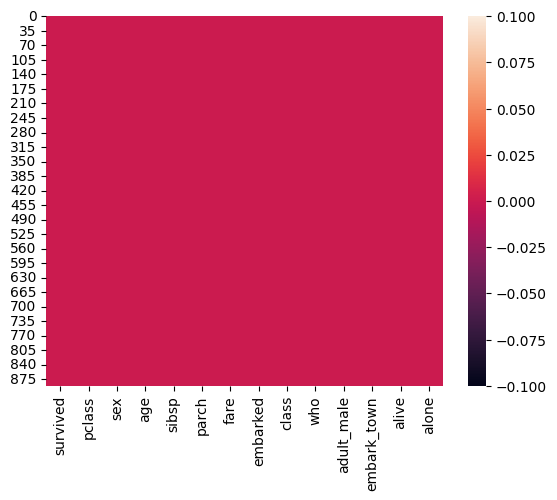

In [36]:
sns.heatmap(df.isnull())

# **Assignment**: if you do not impute or handle missing values, what will happen?

# **Bining**

In [37]:
# Bining is the grouping of numirical data into few catagories to make sense out of it 

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [38]:
df.age.min()

np.float64(0.42)

In [39]:
df.age.max()

np.float64(80.0)

<Axes: xlabel='age', ylabel='Count'>

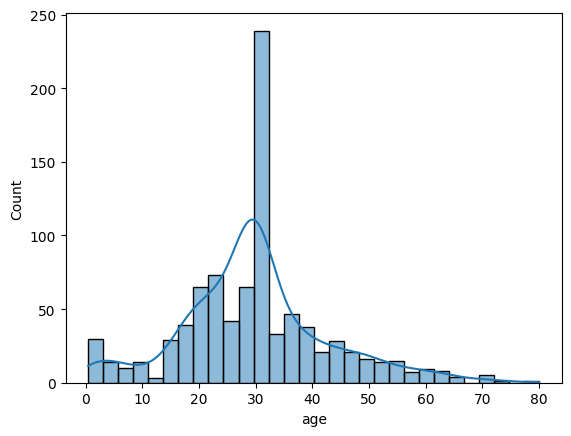

In [40]:
sns.histplot(df.age,bins = 30,kde = True)

In [41]:
# import plotly.express as px
# # change the edgecolor of line to black
# fig = px.histogram(df, x="age", nbins=50)
# fig.update_traces(marker=dict(line=dict(color='black', width=1)))
# fig.show()



In [42]:
# import plotly.express as px
# import plotly.graph_objects as go
# from scipy.stats import gaussian_kde
# import numpy as np

# fig = px.histogram(df, x="age", nbins=50)
# fig.update_traces(marker=dict(line=dict(color='black', width=1)))

# # Calculate KDE
# age = df['age'].dropna()
# kde = gaussian_kde(age)
# x_vals = np.linspace(age.min(), age.max(), 200)
# y_vals = kde(x_vals) * len(age) * (age.max()-age.min())/50  # scale to histogram

# # Add KDE line
# fig.add_trace(go.Scatter(x=x_vals, y=y_vals, mode='lines', name='KDE', line=dict(color='red')))

# fig.show()

In [43]:
# binning of age column into 7 categories
bins = [0,1,5,12,18,30,50,80]
labels = ['Infant','Toddlers','Kids','Teens','Youngs','Middle Aged','Old']

pd.cut(df['age'], bins=bins, labels=labels)

0           Youngs
1      Middle Aged
2           Youngs
3      Middle Aged
4      Middle Aged
          ...     
886         Youngs
887         Youngs
888         Youngs
889         Youngs
890    Middle Aged
Name: age, Length: 891, dtype: category
Categories (7, object): ['Infant' < 'Toddlers' < 'Kids' < 'Teens' < 'Youngs' < 'Middle Aged' < 'Old']

# Feature Engineering

In [44]:
# binning of age column into 7 categories
bins = [0,1,5,12,18,30,50,80]
labels = ['Infant','Toddlers','Kids','Teens','Youngs','Middle Aged','Old']

df['binned_age'] = pd.cut(df['age'], bins=bins, labels=labels)

In [45]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,binned_age
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,Youngs
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,Middle Aged
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,Youngs
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,Middle Aged
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,Middle Aged


In [48]:
df['age_groups'].value_counts()

age_groups
Youngs         447
Middle Aged    241
Teens           70
Old             64
Toddlers        30
Kids            25
Infant          14
Name: count, dtype: int64

# renaming a column

In [47]:
df.rename(columns={'binned_age':'age_groups'},inplace = True)

In [49]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,age_groups
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,Youngs
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,Middle Aged
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,Youngs
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,Middle Aged
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,Middle Aged


In [50]:
df.groupby('age_groups')['survived'].sum()

age_groups
Infant          12
Toddlers        19
Kids             9
Teens           30
Youngs         148
Middle Aged    102
Old             22
Name: survived, dtype: int64

In [51]:

df.survived.sum()


np.int64(342)

# Data filtring

In [52]:
# based on columns
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone', 'age_groups'],
      dtype='object')

In [53]:
df_01 = df[['survived','age_groups','fare','class']]
df_01.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   survived    891 non-null    int64   
 1   age_groups  891 non-null    category
 2   fare        891 non-null    float64 
 3   class       891 non-null    category
dtypes: category(2), float64(1), int64(1)
memory usage: 16.3 KB


In [54]:
df['class'].value_counts()

class
Third     491
First     216
Second    184
Name: count, dtype: int64

In [59]:
# filter the data based on rows criteria

df_first = df_01[df_01['class'] == 'First']


In [56]:
# lets select only those who rows which have paid more than 200 Pounds
df_200 = df_01[df_01['fare'] > 50]
df_200.info()

<class 'pandas.core.frame.DataFrame'>
Index: 160 entries, 1 to 879
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   survived    160 non-null    int64   
 1   age_groups  160 non-null    category
 2   fare        160 non-null    float64 
 3   class       160 non-null    category
dtypes: category(2), float64(1), int64(1)
memory usage: 4.5 KB


In [57]:
df_200['class'].value_counts()

class
First     139
Third      14
Second      7
Name: count, dtype: int64

In [67]:
# how to add two filters
df_01[(df_01['fare'] > 70) & (df_01['class'] == 'First')].sort_values(by = 'fare',ascending = True)

,survived,age_groups,fare,class
540,1,Middle Aged,71.0000,First
745,0,Old,71.0000,First
1,1,Middle Aged,71.2833,First
366,1,Old,75.2500,First
218,1,Middle Aged,76.2917,First
...,...,...,...,...
438,0,Old,263.0000,First
27,0,Youngs,263.0000,First
679,1,Middle Aged,512.3292,First
258,1,Middle Aged,512.3292,First
